# 08b — 3D inundation & illustrative hydrodynamics

Two clearly-separated things, both on the step-03 corrected DTM (the talar — the
wetland-transition zone):

**A. Progressive flood-stage inundation (defensible).** A 3D terrain with a rising
flat water plane — cells flood where ground elevation < stage. This is *geometry
only* (no invented dynamics): it answers "if the floodplain rises to elevation W,
what floods?". Output as a static 3D image, a rising-stage GIF, and an **interactive
HTML** embedded in the step-09 web map.

**B. Illustrative overland flow (NOT a result).** Landlab's `OverlandFlow`
shallow-water solver under a *synthetic uniform rainfall* pulse. We have **no**
rainfall / river-stage / inflow data, so this only shows how water would route over
the measured terrain. It is labelled illustrative everywhere and must not be read as
a calibrated flood prediction.

z is exaggerated ×5 for display (the floodplain relief is only a few metres).

**Inputs:** `outputs/03_corrected/talar_dtm_corrected_0p5m.tif`.
**Outputs:** `outputs/08b_3d/` — 3D images, rising-flood GIF, interactive HTML,
illustrative overland-flow figures.

In [1]:
from pathlib import Path
import numpy as np
import rasterio

from drone_reserve.viz3d import render_inundation, flood_gif, overland_flow_demo

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent; break
else:
    raise RuntimeError("repo root not found")

DTM = REPO / "outputs" / "03_corrected" / "talar_dtm_corrected_0p5m.tif"
OUT = REPO / "outputs" / "08b_3d"
OUT.mkdir(parents=True, exist_ok=True)
EXAG = 5.0  # vertical exaggeration for display

# Flood stages = elevation percentiles of the valid terrain (skip the deep-pit tail).
with rasterio.open(DTM) as s:
    z = s.read(1, masked=True).compressed()
STAGES = [round(float(v), 2) for v in np.percentile(z, [10, 25, 40, 55, 70])]
print(f"valid terrain z: {z.min():.2f}–{z.max():.2f} m")
print(f"flood stages (m): {STAGES}")

valid terrain z: 11.52–32.49 m
flood stages (m): [21.32, 21.98, 22.25, 22.71, 23.76]


## A. Static 3D inundation at a representative stage

Terrain coloured by elevation; translucent blue water where ground < stage.

stage 22.25 m floods 4.84 ha


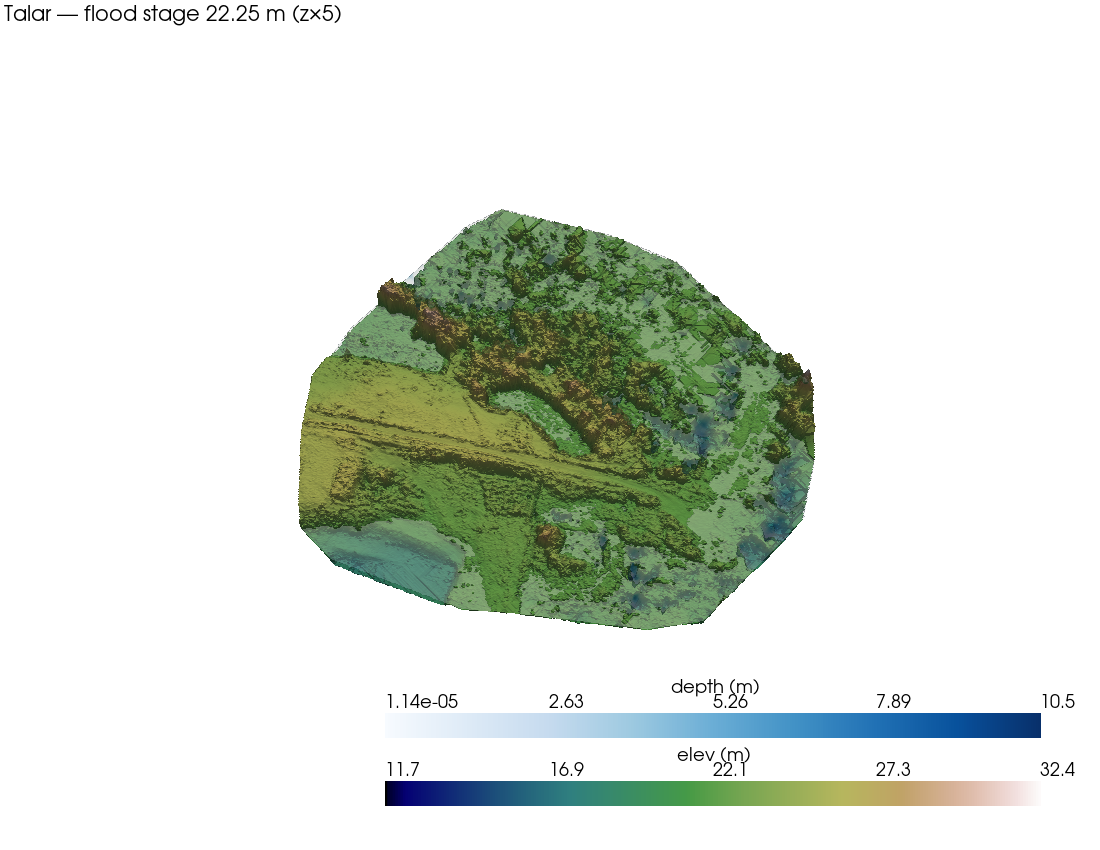

In [2]:
stage = STAGES[2]  # ~40th-percentile elevation
info = render_inundation(DTM, stage, out_png=str(OUT / "talar_inundation_3d.png"),
                         exag=EXAG, downsample=2,
                         title=f"Talar — flood stage {stage:.2f} m (z×{EXAG:g})")
print(f"stage {stage:.2f} m floods {info['flooded_ha']} ha")
from IPython.display import Image
Image(str(OUT / "talar_inundation_3d.png"))

## Interactive HTML (for the step-09 web map)

Self-contained vtk.js scene — rotate/zoom in a browser. Downsampled for a smaller file.

In [3]:
render_inundation(DTM, stage, out_html=str(OUT / "talar_inundation_3d.html"),
                  exag=EXAG, downsample=3,
                  title=f"Talar — flood stage {stage:.2f} m")
html = OUT / "talar_inundation_3d.html"
print(f"wrote {html.name}: {html.stat().st_size/1e6:.1f} MB (embed in step 09)")

wrote talar_inundation_3d.html: 3.8 MB (embed in step 09)


## Rising-flood animation

Water level steps through the five stages — low depressions (tosqueras) fill first,
then connect.

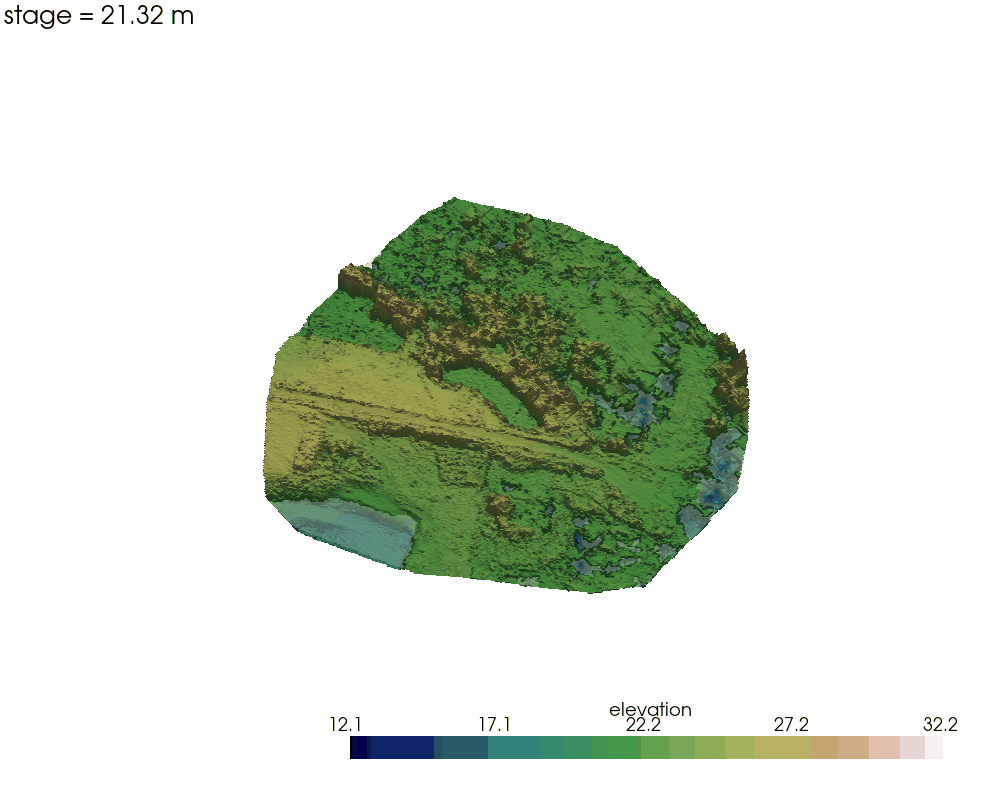

In [4]:
flood_gif(DTM, STAGES, str(OUT / "talar_flood_rising.gif"), exag=EXAG, downsample=3)
from IPython.display import Image as IPImage
IPImage(str(OUT / "talar_flood_rising.gif"))

## B. ILLUSTRATIVE overland flow (synthetic rainfall — not a prediction)

Landlab `OverlandFlow` (de Almeida shallow-water solver) under a uniform 50 mm/hr
rainfall for 30 min, perimeter open as outlets. **No site rainfall/inflow data
exist** — this only illustrates routing over the measured terrain.

ILLUSTRATIVE: max water depth 2.76 m, wet area 2.92 ha


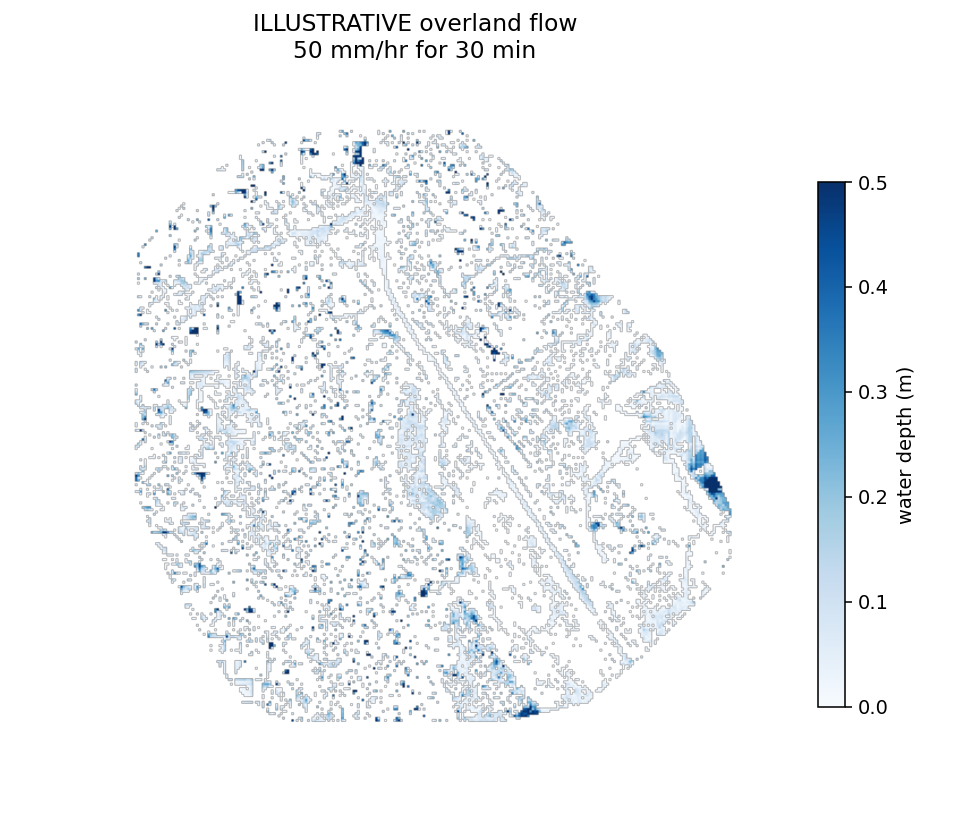

In [5]:
res = overland_flow_demo(DTM, str(OUT), rain_mm_hr=50.0, duration_min=30.0,
                         dt_s=2.0, downsample=3, exag=EXAG)
print(f"ILLUSTRATIVE: max water depth {res['max_depth_m']:.2f} m, "
      f"wet area {res['wet_area_ha']} ha")
from IPython.display import Image as IPImg
IPImg(res["depth_png"])

## Findings & caveats

- **A (flood-stage) is defensible** — pure geometry on the measured DTM; the rising-
  flood sequence shows the tosqueras/wetland depressions filling first, consistent with
  step 08's depression analysis.
- **B (overland flow) is illustrative only** — driven by synthetic rainfall because the
  site has no rainfall / river-stage / inflow data; treat the depths/extents as a
  visualization of terrain routing, not a calibrated prediction.
- Both inherit the corrected DTM's under-canopy interpolation uncertainty (step-03
  confidence layer) and the flat-floodplain caveat from step 08.
- The interactive HTML (`talar_inundation_3d.html`) is embedded in the step-09 web map.
- z exaggerated ×5 for display; flood stages are elevation percentiles (the deep-pit
  tail is excluded so stages are meaningful).